# TASK #1: UNDERSTAND THE PROBLEM STATEMENT  

![image.png](attachment:image.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)

# TASK #2: IMPORT LIBRARIES AND DATASETS

In [20]:

!pip install jupyterthemes


In [21]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import matplotlib.pyplot as plt
from jupyterthemes import jtplot
jtplot.style(theme = 'monokai', context = 'notebook', ticks = True, grid = False)
# setting the style of the notebook to be monokai theme
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them.


In [84]:
# Use the same dataset made readily available by keras Using the following lines of code:
(X_train, y_train) , (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


**PRACTICE OPPORTUNITY #1:**
- **Check out the sizes of both training and testing datasets**

In [69]:

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)
X_test shape: (10000, 28, 28, 1, 1)
y_test shape: (10000,)


# TASK #3: PERFORM DATA VISUALIZATION

8


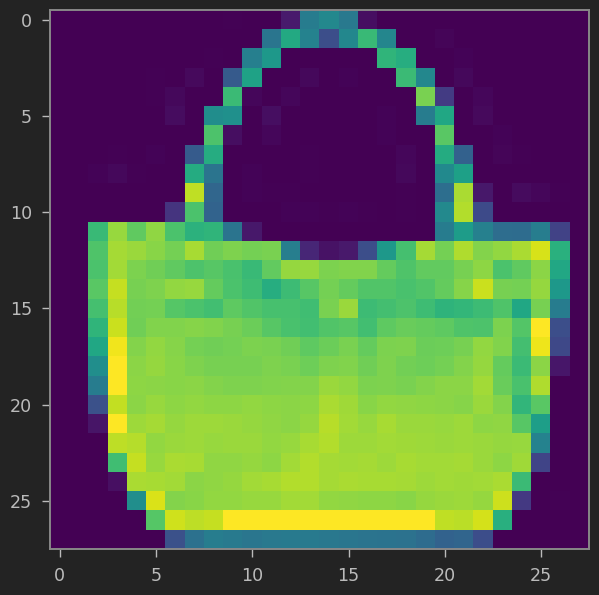

In [24]:
# Select a sample image and visualize it
i = 100
plt.imshow(X_train[i])
print(y_train[i])

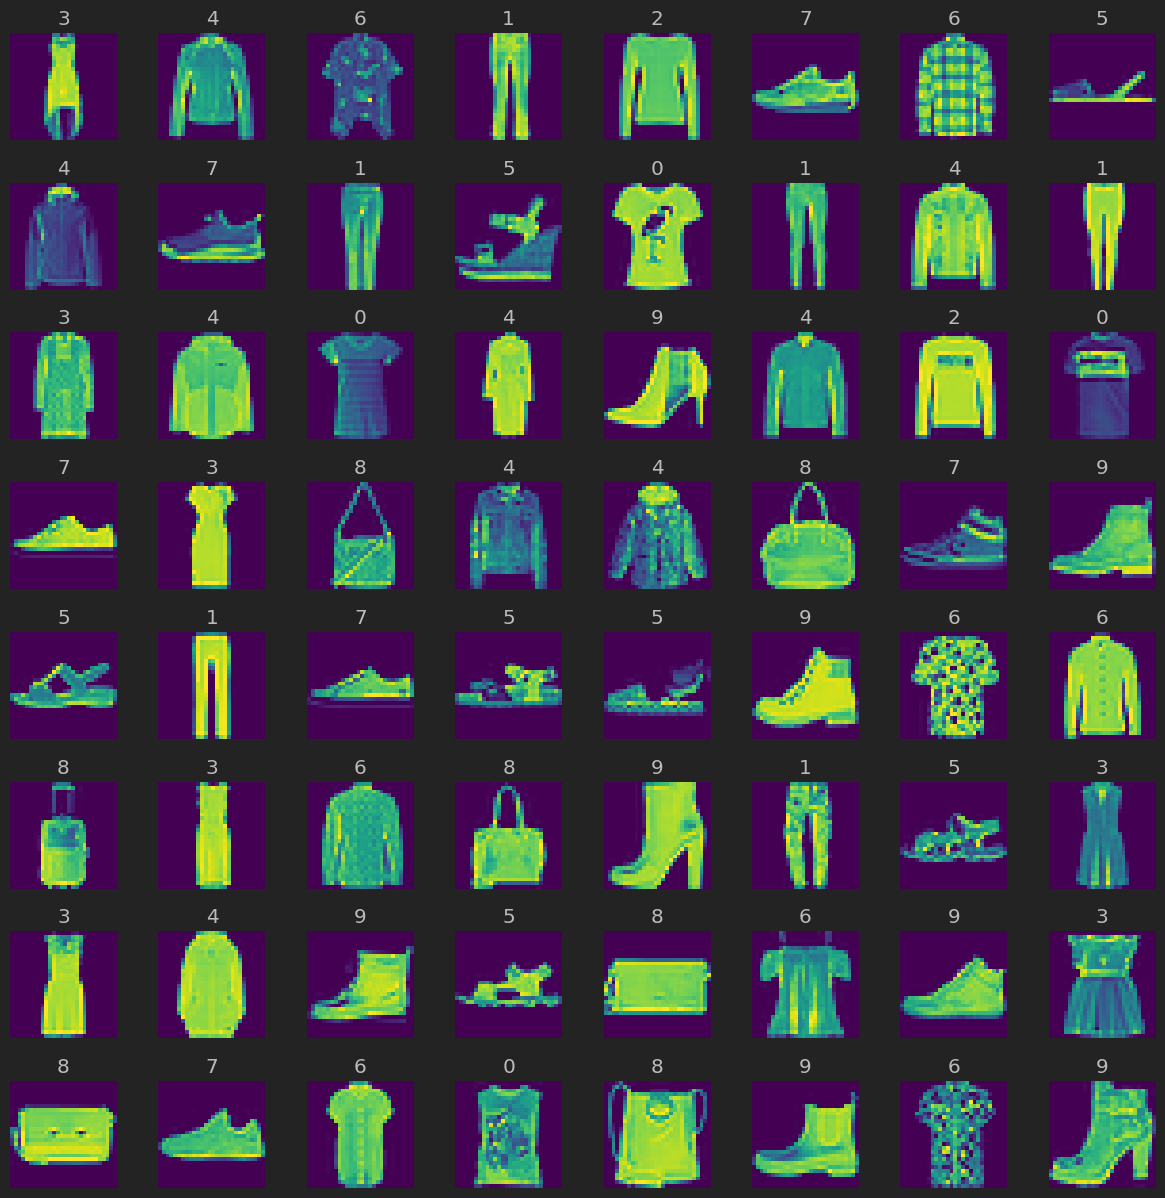

In [25]:
# Remember the 10 classes decoding is as follows:
# 0 => T-shirt/top
# 1 => Trouser
# 2 => Pullover
# 3 => Dress
# 4 => Coat
# 5 => Sandal
# 6 => Shirt
# 7 => Sneaker
# 8 => Bag
# 9 => Ankle boot


W_grid = 8
L_grid = 8

fig, axes = plt.subplots(L_grid, W_grid, figsize = (15, 15))
axes = axes.ravel()

n_training = len(X_train)

for i in np.arange(0, L_grid * W_grid):
    index = np.random.randint(0, n_training) # pick a random number
    axes[i].imshow(X_train[index])
    axes[i].set_title(y_train[index])
    axes[i].axis('off')

plt.subplots_adjust(hspace = 0.4)

**PRACTICE OPPORTUNITY #2:**
- **Plot a grid containing 144 images and perform a sanity check on the data**

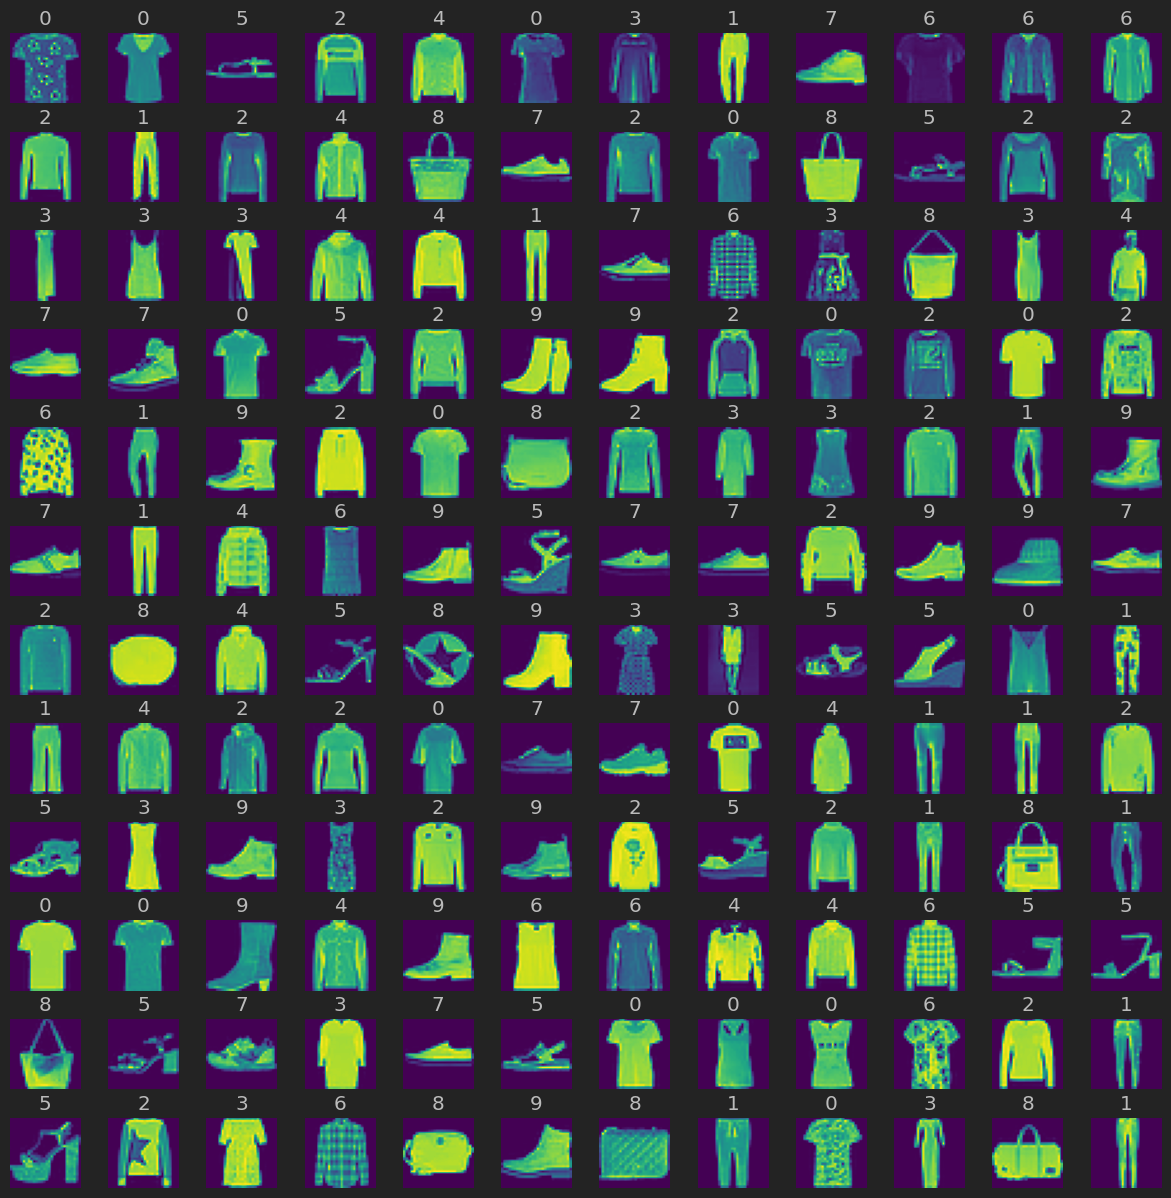

In [26]:

W_grid = 12
L_grid = 12

fig, axes = plt.subplots(L_grid, W_grid, figsize = (15, 15))
axes = axes.ravel()

n_training = len(X_train)

for i in np.arange(0, L_grid * W_grid):
    index = np.random.randint(0, n_training) # pick a random number
    axes[i].imshow(X_train[index])
    axes[i].set_title(y_train[index])
    axes[i].axis('off')

plt.subplots_adjust(hspace = 0.4)


In [ ]:

print(y_train.value_counts())
print(y_test.value_counts())


print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


# TASK #4: PREPARE THE DATA FOR TRAINING

In [85]:
number_cat = 10
y_train = tf.keras.utils.to_categorical(y_train, number_cat)

In [29]:
X_train.shape

(60000, 28, 28)

In [30]:
y_train.shape

(60000, 10)

In [31]:
y_train

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [32]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [86]:
y_test = tf.keras.utils.to_categorical(y_test, number_cat)

In [87]:
X_train.shape

(60000, 28, 28)

In [88]:
X_train = np.expand_dims(X_train, axis=-1)

In [89]:
X_train.shape

(60000, 28, 28, 1)

In [90]:
y_train.shape

(60000, 10)

# TASK #5: BUILD A DEEP LEARNING MODEL

![image.png](attachment:image.png)

In [38]:
from tensorflow.keras import datasets, layers, models
cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)  ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(64, activation = 'relu'))
cnn.add(layers.Dense(10, activation = 'softmax'))
cnn.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 3, 3, 64)          36928     
                                                                 
 flatten_1 (Flatten)         (None, 576)              

# TASK #6: COMPILE AND TRAIN A DEEP LEARNING MODEL

In [39]:
cnn.compile(optimizer = tf.keras.optimizers.legacy.RMSprop(0.0001, decay = 1e-6), loss ='categorical_crossentropy', metrics =['accuracy'])

In [40]:
X_train.shape

(60000, 28, 28, 1)

In [41]:
epochs = 10

history = cnn.fit(X_train, y_train, batch_size = 512, epochs = epochs)

Epoch 1/10
118/118 [==============================] - 51s 414ms/step - loss: 2.3042 - accuracy: 0.5767
Epoch 2/10
118/118 [==============================] - 46s 392ms/step - loss: 0.7030 - accuracy: 0.7586
Epoch 3/10
118/118 [==============================] - 48s 410ms/step - loss: 0.5677 - accuracy: 0.8002
Epoch 4/10
118/118 [==============================] - 46s 387ms/step - loss: 0.4939 - accuracy: 0.8268
Epoch 5/10
118/118 [==============================] - 47s 401ms/step - loss: 0.4480 - accuracy: 0.8404
Epoch 6/10
118/118 [==============================] - 48s 405ms/step - loss: 0.4139 - accuracy: 0.8526
Epoch 7/10
118/118 [==============================] - 46s 391ms/step - loss: 0.3849 - accuracy: 0.8626
Epoch 8/10
118/118 [==============================] - 49s 419ms/step - loss: 0.3641 - accuracy: 0.8710
Epoch 9/10
118/118 [==============================] - 47s 394ms/step - loss: 0.3455 - accuracy: 0.8764
Epoch 10/10
118/118 [==============================] - 46s 387ms/step - l

# TASK #7: ASSESS TRAINED MODEL PERFORMANCE

In [42]:
X_test.shape

(10000, 28, 28)

In [43]:
X_test = np.expand_dims(X_test, axis=-1)

In [44]:
X_test.shape

(10000, 28, 28, 1)

In [45]:
y_test.shape

(10000, 10)

In [46]:
X_test = X_test.astype('float')


In [47]:
predicted_classes = cnn.predict(X_test)

313/313 [==============================] - 4s 12ms/step


In [48]:
predicted_classes

array([[7.0296541e-05, 4.3382252e-06, 1.6010301e-05, ..., 3.5826524e-03,
        4.4766974e-05, 9.9581456e-01],
       [7.2238698e-05, 1.3534336e-06, 9.9965119e-01, ..., 1.9704494e-10,
        1.9995574e-09, 3.1798468e-09],
       [7.7529421e-08, 9.9999982e-01, 6.3870091e-09, ..., 5.9911310e-13,
        3.9986917e-11, 3.9768311e-15],
       ...,
       [3.8405991e-04, 4.7643059e-08, 5.4779541e-08, ..., 1.8056856e-09,
        9.9954110e-01, 9.7112063e-10],
       [1.6379509e-07, 9.9998695e-01, 3.1965324e-06, ..., 9.0525959e-10,
        7.0164702e-10, 2.0081705e-11],
       [3.0945698e-03, 1.5033565e-03, 3.4292645e-03, ..., 6.7027259e-01,
        5.6642029e-02, 6.6333242e-02]], dtype=float32)

In [49]:
predicted_classes=np.argmax(predicted_classes,axis=1)


In [50]:
predicted_classes

array([9, 2, 1, ..., 8, 1, 7])

In [51]:
y_test

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [52]:
y_test = y_test.argmax(1)

In [53]:
y_test

array([9, 2, 1, ..., 8, 1, 5])

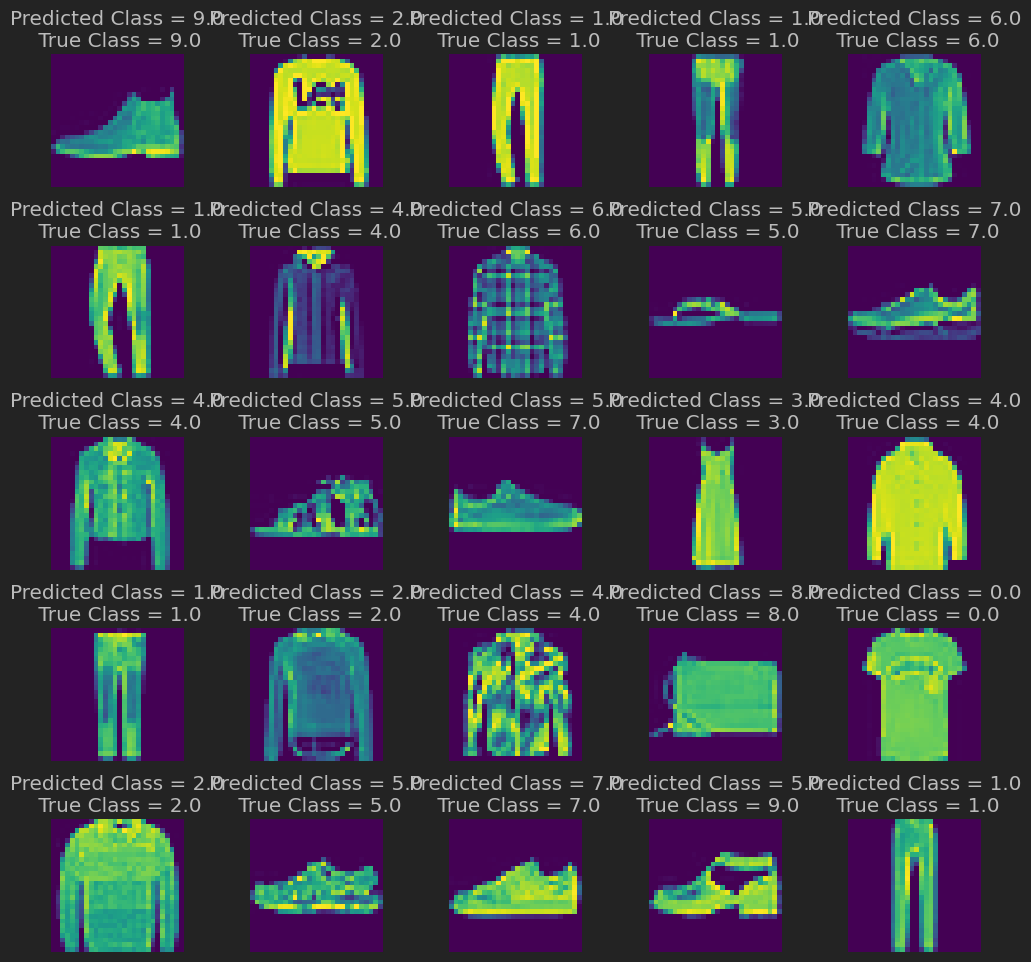

In [54]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel() #

for i in np.arange(0, L * W):
    axes[i].imshow(X_test[i].reshape(28,28))
    axes[i].set_title("Predicted Class = {:0.1f}\n True Class = {:0.1f}".format(predicted_classes[i], y_test[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

<Axes: >

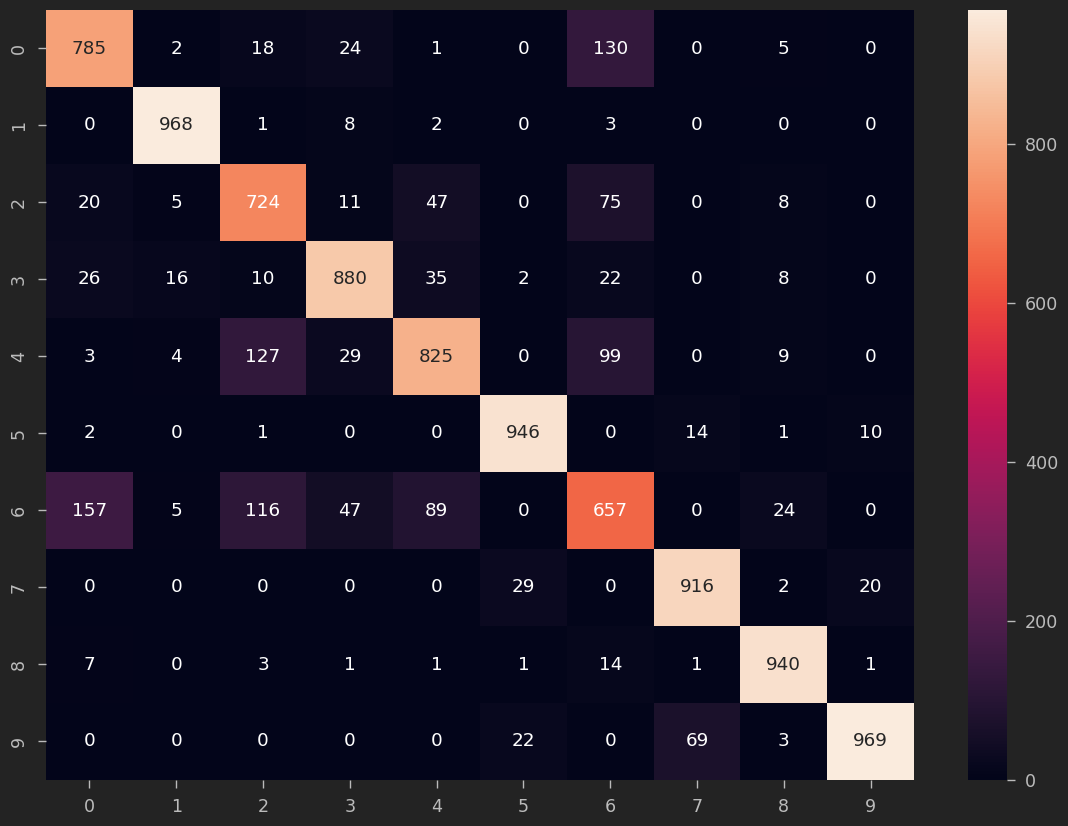

In [63]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(predicted_classes, y_test)
plt.figure(figsize = (14, 10))
sns.heatmap(cm, annot = True, fmt = 'd')

In [65]:
from sklearn.metrics import classification_report
num_classes = 10
target_names = ['class {}'.format(i) for i in range(num_classes)]

print(classification_report(y_test, predicted_classes, target_names = target_names))

              precision    recall  f1-score   support

     class 0       0.81      0.79      0.80      1000
     class 1       0.99      0.97      0.98      1000
     class 2       0.81      0.72      0.77      1000
     class 3       0.88      0.88      0.88      1000
     class 4       0.75      0.82      0.79      1000
     class 5       0.97      0.95      0.96      1000
     class 6       0.60      0.66      0.63      1000
     class 7       0.95      0.92      0.93      1000
     class 8       0.97      0.94      0.95      1000
     class 9       0.91      0.97      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



**PRACTICE OPPORTUNITY #3:**
- **Add a new dense layer containing 1024 neurons**
- **Increase the number of epochs**
- **Plot the model summary and determine the number of trainable parameters**
- **Retrain the model and evaluate its performance**

In [71]:
cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)  ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(64, activation = 'relu'))
cnn.add(layers.Dense(1024, activation = 'relu'))
cnn.add(layers.Dense(10, activation = 'softmax'))
cnn.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 13, 13, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_16 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 5, 5, 64)          0         
 ng2D)                                                           
                                                                 
 conv2d_17 (Conv2D)          (None, 3, 3, 64)          36928     
                                                                 
 flatten_5 (Flatten)         (None, 576)              

In [91]:
cnn.compile(optimizer = tf.keras.optimizers.legacy.RMSprop(0.0001, decay = 1e-6), loss ='categorical_crossentropy', metrics =['accuracy'])

In [92]:
epochs = 20

history = cnn.fit(X_train, y_train, batch_size = 512, epochs = epochs)

Epoch 1/20
118/118 [==============================] - 51s 421ms/step - loss: 0.2241 - accuracy: 0.9181
Epoch 2/20
118/118 [==============================] - 47s 397ms/step - loss: 0.2149 - accuracy: 0.9214
Epoch 3/20
118/118 [==============================] - 48s 406ms/step - loss: 0.2101 - accuracy: 0.9238
Epoch 4/20
118/118 [==============================] - 50s 421ms/step - loss: 0.2031 - accuracy: 0.9263
Epoch 5/20
118/118 [==============================] - 48s 403ms/step - loss: 0.1970 - accuracy: 0.9280
Epoch 6/20
118/118 [==============================] - 49s 412ms/step - loss: 0.1932 - accuracy: 0.9286
Epoch 7/20
118/118 [==============================] - 48s 409ms/step - loss: 0.1878 - accuracy: 0.9313
Epoch 8/20
118/118 [==============================] - 48s 410ms/step - loss: 0.1835 - accuracy: 0.9322
Epoch 9/20
118/118 [==============================] - 47s 398ms/step - loss: 0.1796 - accuracy: 0.9333
Epoch 10/20
118/118 [==============================] - 47s 400ms/step - l

In [93]:
X_test.shape

(10000, 28, 28)

In [94]:
X_test = np.expand_dims(X_test, axis=-1)

In [95]:
X_test.shape

(10000, 28, 28, 1)

In [96]:
y_test.shape

(10000, 10)

In [97]:
X_test = X_test.astype('float')


In [98]:
predicted_classes = cnn.predict(X_test)

313/313 [==============================] - 3s 11ms/step


In [99]:
predicted_classes

array([[2.5104218e-06, 1.3630830e-12, 3.1916068e-07, ..., 9.2301583e-05,
        8.4022339e-08, 9.9990255e-01],
       [2.4815924e-08, 3.5923035e-17, 9.9999756e-01, ..., 6.7612992e-21,
        2.7861922e-13, 3.2539419e-17],
       [9.1399726e-12, 9.9999994e-01, 2.4176422e-16, ..., 1.5212637e-28,
        4.2656042e-16, 1.8690865e-23],
       ...,
       [4.1943090e-12, 2.5892029e-17, 1.5113734e-12, ..., 1.6716934e-20,
        9.9999994e-01, 2.0349640e-18],
       [1.5173992e-11, 9.9999994e-01, 2.0235096e-12, ..., 1.6068947e-16,
        5.0646390e-13, 1.8632219e-14],
       [2.7351215e-04, 9.8527950e-09, 7.8826510e-05, ..., 3.5927253e-04,
        1.6836548e-05, 4.4220531e-05]], dtype=float32)

In [100]:
predicted_classes=np.argmax(predicted_classes,axis=1)


In [101]:
predicted_classes

array([9, 2, 1, ..., 8, 1, 5])

In [102]:
y_test

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [103]:
y_test = y_test.argmax(1)

In [104]:
y_test

array([9, 2, 1, ..., 8, 1, 5])

<Axes: >

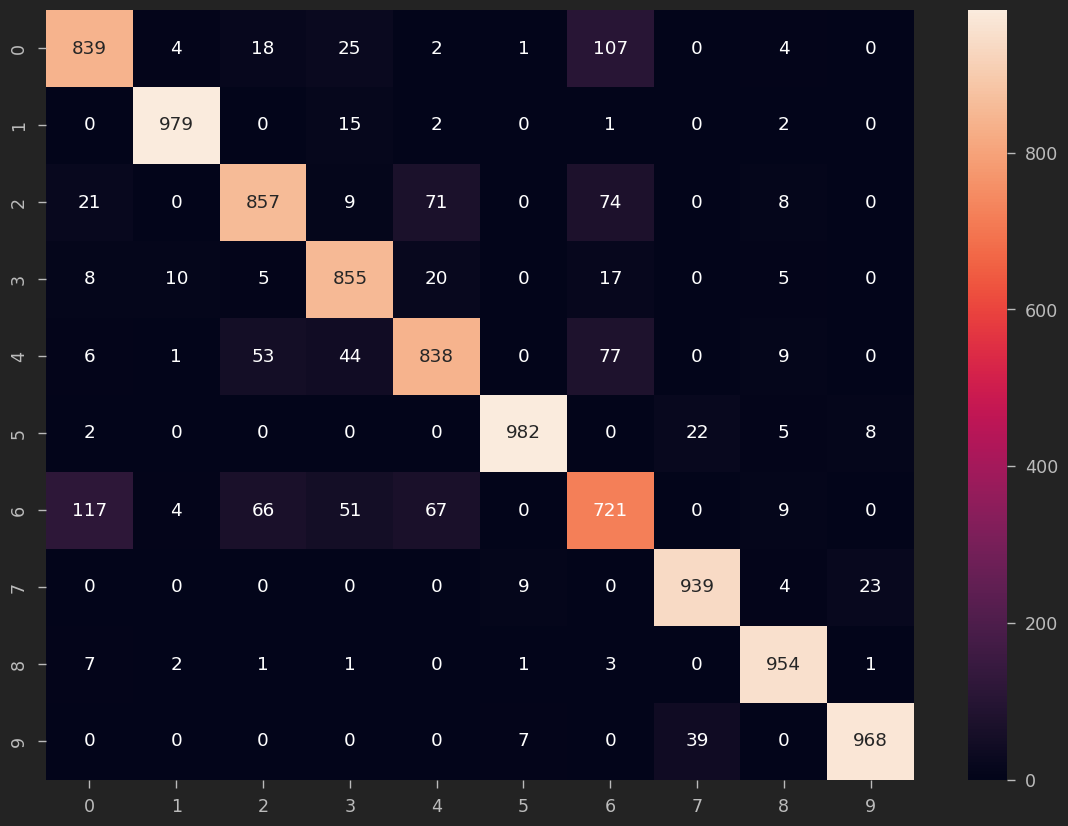

In [111]:

cm = confusion_matrix(predicted_classes, y_test)
plt.figure(figsize = (14, 10))
sns.heatmap(cm, annot = True, fmt = 'd')

In [112]:

num_classes = 10
target_names = ['class {}'.format(i) for i in range(num_classes)]

print(classification_report(y_test, predicted_classes, target_names = target_names))

              precision    recall  f1-score   support

     class 0       0.84      0.84      0.84      1000
     class 1       0.98      0.98      0.98      1000
     class 2       0.82      0.86      0.84      1000
     class 3       0.93      0.85      0.89      1000
     class 4       0.82      0.84      0.83      1000
     class 5       0.96      0.98      0.97      1000
     class 6       0.70      0.72      0.71      1000
     class 7       0.96      0.94      0.95      1000
     class 8       0.98      0.95      0.97      1000
     class 9       0.95      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



# GREAT JOB!

# PRACTICE OPPORTUNITIES SOLUTIONS

**PRACTICE OPPORTUNITY #1 SOLUTION:**
- **Check out the sizes of both training and testing datasets**

In [105]:
X_train.shape

(60000, 28, 28, 1)

In [106]:
X_test.shape

(10000, 28, 28, 1)

In [107]:
y_train.shape

(60000, 10)

In [108]:
y_test.shape

(10000,)

**PRACTICE OPPORTUNITY #2 SOLUTION:**
- **Plot a grid containing 144 images and perform a sanity check on the data**

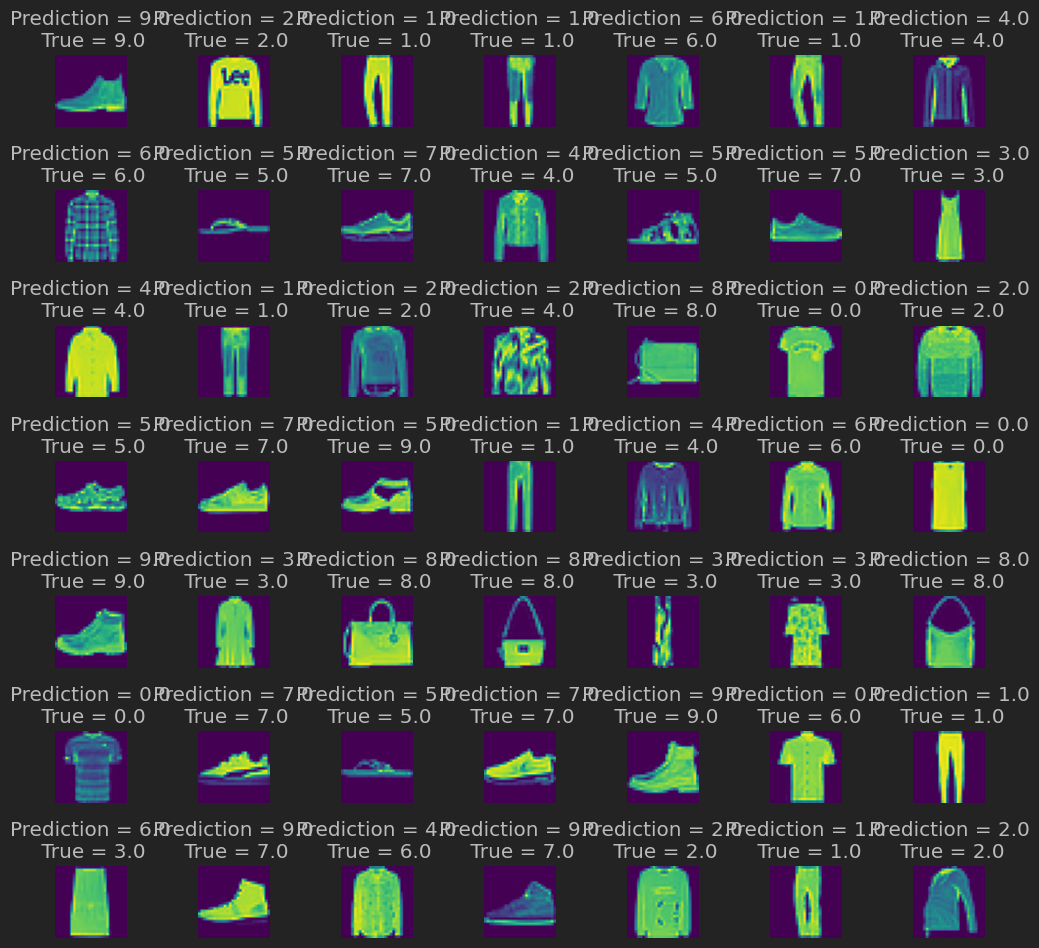

In [109]:
L = 7
W = 7
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(X_test[i].reshape(28,28))
    axes[i].set_title("Prediction = {:0.1f}\n True = {:0.1f}".format(predicted_classes[i], y_test[i]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)

**PRACTICE OPPORTUNITY #3 SOLUTION:**
- **Add a new dense layer containing 1024 neurons**
- **Increase the number of epochs**
- **Plot the model summary and determine the number of trainable parameters**
- **Retrain the model and evaluate its performance**

In [110]:
from tensorflow.keras import datasets, layers, models
cnn = models.Sequential()

cnn.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)  ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))
cnn.add(layers.MaxPooling2D(2,2))

cnn.add(layers.Conv2D(64, (3,3), activation = 'relu' ))

cnn.add(layers.Flatten())

cnn.add(layers.Dense(64, activation = 'relu'))
cnn.add(layers.Dense(1000, activation = 'relu'))
cnn.add(layers.Dense(10, activation = 'softmax'))
cnn.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 13, 13, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_19 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPooli  (None, 5, 5, 64)          0         
 ng2D)                                                           
                                                                 
 conv2d_20 (Conv2D)          (None, 3, 3, 64)          36928     
                                                                 
 flatten_6 (Flatten)         (None, 576)              